# Introdução ao Web Scraping com Playwright

O **Playwright** é uma ferramenta moderna para automação de navegadores que permite realizar *web scraping* de forma rápida, segura e altamente configurável. Diferente de bibliotecas tradicionais como `requests` ou `BeautifulSoup`, o Playwright pode interagir com páginas dinâmicas que utilizam **JavaScript**, **AJAX** e **renderização assíncrona**, simulando o comportamento real de um usuário no navegador.

## 🧭 Por que usar o Playwright?

O Playwright é ideal para páginas dinâmicas e complexas. Ele oferece:
- Suporte a múltiplos navegadores (Chromium, Firefox e WebKit).
- Suporte nativo a **esperas automáticas** e **seletores inteligentes**.
- Controle avançado de **cookies**, **storage** e **user agents**.
- Execução **paralela** e **isolada** em contextos diferentes.


### ⚙️ Instalação

```bash
pip install playwright
playwright install
```


#### 🧪 Versão assíncrona

In [28]:
import asyncio
from playwright.async_api import async_playwright


async with async_playwright() as p:
    browser = await p.chromium.launch(headless=False)
    page = await browser.new_page()
    await page.goto("https://g1.globo.com", wait_until='domcontentloaded', timeout=2000)
    await browser.close()


### Paralelismo no python

> __Processos__ são programas em execução.

Programas podem executar de forma `síncrona` e `assíncrona`. 

#### O que é um processo "síncrono" ou “assíncrono”?

<center>
<img src="https://blognti.wordpress.com/wp-content/uploads/2010/07/requisicoes1.jpg">
</center>

Em um programa __síncrono__, as instruções são executadas uma de cada vez, em sequência.
O código “espera” a linha anterior terminar antes de seguir.

Já em um programa __assíncrono__, várias tarefas podem ocorrer em paralelo — enquanto uma linha está esperando uma resposta (por exemplo, o carregamento de uma página), o Python pode continuar executando outras.

### ⚙️ O papel do await

O __await__ é o comando que pausa a execução da função atual até que a operação assíncrona termine, sem travar o restante do programa.

Ou seja:

Ele espera o resultado de uma tarefa assíncrona, mas libera o processador para outras tarefas enquanto isso acontece.

### Versão síncrona

In [53]:
#pip install playwright
import asyncio
from playwright.async_api import async_playwright


async def main():
    async with async_playwright() as p:
        browser = await p.chromium.launch(headless=False)
        page = await browser.new_page()
#        await page.goto("https://g1.globo.com", timeout=6000)        
#        await page.goto("https://g1.globo.com", wait_until='domcontentloaded')        
#        await page.goto("https://g1.globo.com", wait_until='networkidle')
        await page.goto("https://g1.globo.com", wait_until='networkidle', timeout=6000)        
        print(await page.title())
        await page.screenshot(path="tela_sync.png")
        await browser.close()

await main()


TimeoutError: Page.goto: Timeout 6000ms exceeded.
Call log:
  - navigating to "https://g1.globo.com/", waiting until "networkidle"


In [41]:
import asyncio

async def tarefa(id_tarefa, tempo):
    print(f'Inicio da tarefa {id_tarefa}.')
    await asyncio.sleep(tempo)
    print(f'Fim da tarefa {id_tarefa}.')

async def main():
    await asyncio.gather(
        tarefa('A', 9),
        tarefa('B', 3),
        tarefa('C', 6)
        
    )

await main()

Inicio da tarefa A.
Inicio da tarefa B.
Inicio da tarefa C.
Fim da tarefa B.
Fim da tarefa C.
Fim da tarefa A.


| Tipo de seletor            | Exemplo Playwright                              | Exemplo HTML correspondente                                                   | Descrição / Uso principal                                                                                 |
|----------------------------|--------------------------------------------------|--------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------|
| **CSS (padrão)**           | `page.locator("div#login")`                      | `<div id="login"></div>`                                                       | Seleciona elementos por seletor CSS padrão (id, classe, tag etc.).                                         |
| **ID**                     | `page.locator("#meu-id")`                        | `<div id="meu-id"></div>`                                                      | Seleciona um elemento pelo atributo `id`.                                                                  |
| **Classe**                 | `page.locator(".botao")`                         | `<button class="botao"></button>`                                              | Seleciona pelo atributo `class`.                                                                           |
| **Atributo**               | `page.locator('[name="email"]')`                 | `<input name="email" />`                                                       | Seleciona elementos com base em qualquer atributo HTML.                                                    |
| **Texto exato**            | `page.get_by_text("Entrar")`                     | `<button>Entrar</button>`                                                      | Seleciona elementos cujo texto visível corresponde exatamente ao fornecido.                               |
| **Texto parcial**          | `page.get_by_text("Entr")`                       | `<button>Entrar</button>`                                                      | Seleciona elementos cujo texto contém a substring especificada.                                           |
| **Role (ARIA)**            | `page.get_by_role("button", name="Enviar")`      | `<button>Enviar</button>`                                                      | Seleciona elementos por **funções de acessibilidade** — muito útil para interfaces responsivas.           |
| **Placeholder**            | `page.get_by_placeholder("Email")`               | `<input placeholder="Email" />`                                                | Seleciona `<input>` ou `<textarea>` com determinado placeholder.                                          |
| **Label**                  | `page.get_by_label("Senha")`                     | `<label>Senha <input type="password"></label>`                                 | Seleciona campo de formulário associado a um rótulo.                                                      |
| **Alt text (imagens)**     | `page.get_by_alt_text("Logo")`                   | `<img src="logo.png" alt="Logo">`                                              | Seleciona imagem ou elemento com atributo `alt`.                                                           |
| **Title (atributo)**       | `page.get_by_title("Ajuda")`                     | `<a title="Ajuda">?</a>`                                                       | Seleciona elementos pelo atributo `title`.                                                                 |
| **Teste ID**               | `page.get_by_test_id("login-btn")`               | `<button data-testid="login-btn"></button>`                                    | Seletor voltado para testes automatizados (`data-testid`).                                                |
| **XPath**                  | `page.locator('//button[@id="login"]')`          | `<button id="login">Entrar</button>`                                          | Suporta expressões XPath completas.                                                                       |
| **nth (índice)**           | `page.locator("button").nth(1)`                  | Vários botões no DOM                                                           | Seleciona o elemento pelo índice (0-based).                                                                |
| **has / has-text**         | `page.locator('div:has(button)')`                | `<div><button>OK</button></div>`                                               | Seleciona contêiner que contém um elemento ou texto específico.                                           |
| **Encadeado (>>)**         | `page.locator("form >> text=Entrar")`            | `<form><button>Entrar</button></form>`                                        | Seleciona um elemento **dentro de outro** (escopo refinado).                                             |
| **Pseudo-classes CSS**     | `page.locator("button:first-child")`             | `<div><button>OK</button></div>`                                              | Suporta `:first-child`, `:nth-child`, `:last-of-type`, etc.                                              |
| **Combinação de seletores**| `page.locator('input[placeholder="Email"].ativo')` | `<input placeholder="Email" class="ativo" />`                               | Combina múltiplas condições (atributo + classe, etc.).                                                   |


### Acessos paralelos

In [ ]:
!playwright install chromium

In [ ]:
!playwright install firefox

In [ ]:
!playwright install webkit

### Paginação paralela

In [56]:
import asyncio
from playwright.async_api import async_playwright

async with async_playwright() as p:
    # inicio os navegadores
    chromium, firefox, webkit = await asyncio.gather(
        p.chromium.launch(headless=False),
        p.firefox.launch(headless=False),
        p.webkit.launch(headless=False)
    )

    #abre uma nova página
    pagina_1, pagina_2, pagina_3 = await asyncio.gather(
        chromium.new_page(),
        firefox.new_page(),
        webkit.new_page()
    )

    # acessa o g1
    await asyncio.gather(
        pagina_1.goto('https://g1.globo.com'),
        pagina_2.goto('https://g1.globo.com'),
        pagina_3.goto('https://g1.globo.com')
    )

    # aguarda 10 segundos
    await asyncio.sleep(10_000)


    await chromium.close()
    await firefox.close()
    await webkit.close()



TimeoutError: Page.goto: Timeout 30000ms exceeded.
Call log:
  - navigating to "https://g1.globo.com/", waiting until "load"


## Download de conteúdo

> Download de conteúdo é uma `response` que contém um arquivo dentro do body.

### Request e Response
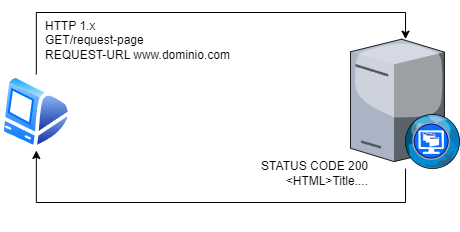

### Head e Body de uma requisição
<img src="http_message.png">

#### 🧪 Lab

In [ ]:
from pathlib import Path
from playwright.async_api import async_playwright

pdf   = 'https://www.w3.org/WAI/ER/tests/xhtml/testfiles/resources/pdf/dummy.pdf'
video = 'https://samplelib.com/lib/preview/mp4/sample-5s.mp4'
audio = 'https://www.soundhelix.com/examples/mp3/SoundHelix-Song-1.mp3'

file = audio
namefile = file.split('/')[-1]

out_dir = Path("downloads"); out_dir.mkdir(exist_ok=True)
target_path = out_dir / namefile

async with async_playwright() as p:
    request = await p.request.new_context()
    resp = await request.get(file)
    
    assert resp.ok, f"Falha no download: {resp.status} {resp.status_text()}"
    
    data = await resp.body()
    target_path.write_bytes(data)
    await request.dispose()

print(f"✅ PDF salvo em: {target_path}")


## Simulação humana

### 1. Conteúdo dos Headers de Requisição (Request)
| Header            | Exemplo                                | Função                                                                                                     |
| ----------------- | -------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| `Host`            | `Host: www.exemplo.com`                | Indica qual domínio está sendo requisitado. Essencial no HTTP/1.1.                                         |
| `User-Agent`      | `User-Agent: Mozilla/5.0 ...`          | Identifica o agente (navegador, app, bot). Frequentemente usado para controle de acesso ou personalização. |
| `Accept`          | `Accept: text/html, application/json`  | Lista os formatos de conteúdo que o cliente aceita na resposta.                                            |
| `Accept-Language` | `Accept-Language: pt-BR, en-US`        | Indica os idiomas preferenciais para a resposta.                                                           |
| `Accept-Encoding` | `Accept-Encoding: gzip, deflate, br`   | Define os tipos de compressão aceitos (melhora performance).                                               |
| `Connection`      | `Connection: keep-alive`               | Indica se a conexão deve ser mantida aberta ou fechada após a resposta.                                    |
| `Referer`         | `Referer: https://google.com`          | URL da página que originou a requisição.                                                                   |
| `Origin`          | `Origin: https://meusite.com`          | Indica a origem da requisição (importante para CORS).                                                      |
| `Authorization`   | `Authorization: Bearer eyJhbGci...`    | Leva tokens ou credenciais de autenticação.                                                                |
| `Cookie`          | `Cookie: sessionid=abc123; theme=dark` | Leva cookies armazenados localmente.                                                                       |
| `Content-Type`    | `Content-Type: application/json`       | Indica o formato do corpo da requisição (usado em POST/PUT).                                               |
| `Content-Length`  | `Content-Length: 254`                  | Tamanho do corpo da requisição em bytes.                                                                   |


### 2. Conteúdo dos Headers de Resposta (Response)

| Header                        | Exemplo                                       | Função                                                |
| ----------------------------- | --------------------------------------------- | ----------------------------------------------------- |
| `Server`                      | `Server: nginx/1.18.0`                        | Identifica o software do servidor.                    |
| `Date`                        | `Date: Tue, 17 Oct 2025 12:00:00 GMT`         | Data e hora da resposta.                              |
| `Content-Type`                | `Content-Type: text/html; charset=UTF-8`      | Tipo e codificação do conteúdo retornado.             |
| `Content-Length`              | `Content-Length: 1024`                        | Tamanho do corpo da resposta.                         |
| `Content-Encoding`            | `Content-Encoding: gzip`                      | Tipo de compressão aplicada.                          |
| `Cache-Control`               | `Cache-Control: no-cache`                     | Instruções de cache para navegadores e proxies.       |
| `Set-Cookie`                  | `Set-Cookie: sessionid=abc123; HttpOnly`      | Define cookies que serão armazenados no cliente.      |
| `Location`                    | `Location: https://nova-url.com`              | Usado em redirecionamentos (códigos 3xx).             |
| `Access-Control-Allow-Origin` | `Access-Control-Allow-Origin: *`              | Usado em CORS para permitir acesso de outras origens. |
| `Strict-Transport-Security`   | `Strict-Transport-Security: max-age=31536000` | Força uso de HTTPS (HSTS).                            |


### 🔐 3. Headers de Segurança Comuns
| Header                    | Função                                                                   |
| ------------------------- | ------------------------------------------------------------------------ |
| `X-Frame-Options`         | Impede que a página seja carregada em um iframe (mitiga clickjacking).   |
| `X-Content-Type-Options`  | Evita detecção automática de tipo de conteúdo (previne ataques MIME).    |
| `Content-Security-Policy` | Define políticas de segurança para carregamento de recursos.             |
| `Referrer-Policy`         | Controla quanta informação de “referer” é enviada.                       |
| `Permissions-Policy`      | Controla quais APIs e recursos o site pode usar (ex: câmera, microfone). |


#### 🧰 4. Headers Especiais ou Personalizados

Além dos padrões, sistemas e APIs costumam usar headers próprios, geralmente prefixados com X- (ou outro nome):

 - X-Requested-With: XMLHttpRequest → comum em requisições AJAX.
 - X-Api-Key: chave_de_api → autenticação de APIs.
 - X-Custom-Header: valor → qualquer header definido pela aplicação.

In [ ]:
# Execute uma vez se necessário:
# !pip install playwright
# !playwright install

from pathlib import Path
from playwright.async_api import async_playwright

URL = "https://bot.sannysoft.com"
USER_DATA_DIR = "user-data-g1"

UA = "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
HDR = {"Accept-Language": "pt-BR,pt;q=0.9,en-US;q=0.8,en;q=0.7"}

# garante pasta do perfil persistente
Path(USER_DATA_DIR).mkdir(parents=True, exist_ok=True)

# --- Célula (assíncrona) para Jupyter ---
async with async_playwright() as p:
    context = await p.chromium.launch_persistent_context(
        USER_DATA_DIR,
        headless=False,
        slow_mo=25,
        viewport={"width": 1366, "height": 768},
        user_agent=UA,
        locale="pt-BR",
        timezone_id="America/Fortaleza",
        color_scheme="light",
        device_scale_factor=1.0,
        is_mobile=False,
        has_touch=False,
        geolocation={"latitude": -3.7327, "longitude": -38.5267},
        permissions=["geolocation"],
        extra_http_headers=HDR,
        accept_downloads=True,
    )

    page = await context.new_page()

    # ----- JS ORIGINAL mantido exatamente como você pediu -----
    await page.add_init_script("""
    navigator.webdriver = false
    Object.defineProperty(navigator, 'webdriver', {
      get: () => false
    })
    """)


    await page.goto(URL, wait_until="domcontentloaded")
    try:
        print("Título:", await page.title())
    except Exception as e:
        print("Erro ao obter título:", e)

    # mantém a página aberta por 2 segundos
    await page.wait_for_timeout(2_000)

    await context.close()


### Cookies

**Cookies** são pequenos arquivos de texto que um site armazena no navegador do usuário quando ele acessa a página.

Eles servem para **memorizar informações** e melhorar a experiência de navegação. Exemplos comuns incluem:

- Manter o usuário **logado** em uma conta.  
- Guardar **preferências** (idioma, modo escuro, etc.).  
- **Rastrear atividades** para análise ou publicidade.

### Tipos de cookies

- **Cookies de sessão**: são apagados quando o navegador é fechado.  
- **Cookies persistentes**: ficam salvos por um tempo definido pelo site, mesmo após fechar o navegador.

### Origem dos cookies

- **Primários (first-party)**: criados pelo próprio site que você acessa.  
- **De terceiros (third-party)**: criados por domínios externos (ex.: redes de anúncios).

> ⚠️ Cookies não executam código, mas podem armazenar identificadores que permitem rastrear atividades.  
> Por isso, estão sujeitos a leis de privacidade como a **:contentReference[oaicite:0]{index=0}** (Brasil) e o **:contentReference[oaicite:1]{index=1}** (UE).


In [ ]:
# arquivo: playwright_cookies_sync.py
from playwright.sync_api import sync_playwright

with sync_playwright() as p:
    browser = p.chromium.launch(headless=False)
    context = browser.new_context()
    page = context.new_page()

    page.goto("https://httpbin.org/cookies/set?c=3&d=4")
    # Capturar cookies via context
    cookies = context.cookies()
    print("Cookies capturados:", cookies)

    # Salvar cookies puros (ou melhor: storage_state)
    context.storage_state(path="storage_state.json")  # salva cookies + localStorage

    # Fechar contexto e criar novo usando o arquivo salvo
    context.close()
    new_context = browser.new_context(storage_state="storage_state.json")
    page2 = new_context.new_page()
    page2.goto("https://httpbin.org/cookies")
    content = page2.content()
    print("Conteúdo com cookies restaurados:", content)

    browser.close()


### Sessões

In [ ]:
# Instalar e preparar o Playwright (caso ainda não tenha feito)
# !pip install playwright
# !playwright install

from pathlib import Path
from playwright.async_api import async_playwright

STATE_FILE = Path("state.json")
URL = "https://example.com"  # ou a página em que você fará login manual

async with async_playwright() as p:
    browser = await p.chromium.launch(headless=False)
    context = await browser.new_context()
    page = await context.new_page()

    # Acessa a página para permitir login ou qualquer outra ação
    await page.goto(URL)
    print("🌐 Navegador aberto — você pode fazer login manual se quiser.")
    await page.wait_for_timeout(2000)  # 15 segundos para interagir manualmente

    # Salva cookies, localStorage e sessionStorage no disco
    await context.storage_state(path=str(STATE_FILE))
    print(f"✅ Estado salvo em: {STATE_FILE.resolve()}")

    await context.close()
    await browser.close()


### Auditoria com Tracing

In [ ]:
# play_g1_trace_har_video_v3.py
# Requisitos:
#   pip install playwright
#   playwright install
#
# Como executar (Jupyter/VSCode Notebook):
#   await run()
#
# Saídas:
#   - trace_g1.zip   → abrir com: playwright show-trace trace_g1.zip
#   - network.har
#   - videos/        → vídeos por página

from pathlib import Path
from playwright.async_api import async_playwright, TimeoutError as PlaywrightTimeout

G1 = "https://g1.globo.com/"

OUT_TRACE = "trace_g1.zip"
OUT_HAR = "network.har"
OUT_VIDEOS = "videos"

HEADLESS = False
SLOW_MO_MS = 0
VIEWPORT = {"width": 1366, "height": 768}


async def click_ceara_editoria(page):
    candidatos = [
        page.get_by_role("link", name="Ceará"),
        page.locator("a:has-text('Ceará')").first,
        page.locator("a[href*='/ce/']").first,
    ]
    for loc in candidatos:
        try:
            if await loc.count() > 0:
                await loc.click(timeout=4000)
                await page.wait_for_load_state("domcontentloaded")
                return True
        except PlaywrightTimeout:
            continue
    return False


async def abrir_uma_materia(page):
    candidatos = [
        page.locator("article a").first,
        page.locator("a[href*='/noticia/']").first,
        page.get_by_role("link").nth(5),
        page.locator("a[href*='/ce/']").nth(3),
    ]
    for loc in candidatos:
        try:
            if await loc.count() > 0:
                await loc.click(timeout=5000)
                await page.wait_for_load_state("domcontentloaded")
                return True
        except PlaywrightTimeout:
            continue
    return False


async def tentar_busca(page, termo="Ceará"):
    # 1) Opcional: tentar revelar a busca
    try:
        candidatos_btn = [
            page.get_by_role("button", name="buscar").first,
            page.get_by_role("button", name="Buscar").first,
            page.locator("button[aria-label*='buscar' i]").first,
            page.locator("button:has(svg)").first,
        ]
        for btn in candidatos_btn:
            if await btn.count():
                try:
                    await btn.click(timeout=1500)
                    break
                except PlaywrightTimeout:
                    pass
    except PlaywrightTimeout:
        pass

    # 2) Procurar form/campo
    form = page.locator("form:has(input[type='search'])").first
    if not await form.count():
        campo = page.locator("input[type='search']").first
        if await campo.count():
            await campo.fill(termo)
            await campo.press("Enter")
            try:
                await page.wait_for_load_state("domcontentloaded")
            except PlaywrightTimeout:
                pass
            return True
        return False

    search = form.locator("input[type='search']").first
    if not await search.count():
        return False

    await search.fill(termo)

    submit = form.locator("button[type='submit'], input[type='submit']").first
    if await submit.count():
        try:
            await submit.click(timeout=3000)
        except PlaywrightTimeout:
            await search.press("Enter")
    else:
        await search.press("Enter")

    try:
        await page.wait_for_load_state("domcontentloaded")
    except PlaywrightTimeout:
        pass

    return True


async def run():
    Path(OUT_VIDEOS).mkdir(parents=True, exist_ok=True)

    async with async_playwright() as p:
        browser = await p.chromium.launch(
            headless=HEADLESS,
            slow_mo=SLOW_MO_MS,
            args=["--start-maximized"],
        )

        context = await browser.new_context(
            viewport=VIEWPORT,
            record_video_dir=OUT_VIDEOS,
            record_har_path=OUT_HAR,
            record_har_mode="full",
            user_agent="Mozilla/5.0 (compatible; PlaywrightTraceDemo/1.2)",
        )

        await context.tracing.start(screenshots=True, snapshots=True, sources=True)

        page = await context.new_page()
        await page.goto(G1, wait_until="domcontentloaded")

        await click_ceara_editoria(page)
        await abrir_uma_materia(page)

        for _ in range(2):
            await page.mouse.wheel(0, 1200)
            await page.wait_for_timeout(600)

        await tentar_busca(page, termo="chuva")

        await context.tracing.stop(path=OUT_TRACE)
        await context.close()
        await browser.close()

# No notebook, execute:
await run()


In [3]:
import pprint
from playwright.async_api import async_playwright

p = await async_playwright().start()
browser = await p.chromium.launch(headless=True)
page = await browser.new_page()

await page.goto("http://quotes.toscrape.com")

quotes_data = []
quote_containers = await page.locator("div.quote").all()

for container in quote_containers:
    text = await container.locator("span.text").inner_text()
    author = await container.locator("small.author").inner_text()
    
    quotes_data.append({
        "texto": text,
        "autor": author
    })

await browser.close()
await p.stop()

pprint.pprint(quotes_data)

[{'autor': 'Albert Einstein',
  'texto': '“The world as we have created it is a process of our thinking. It '
           'cannot be changed without changing our thinking.”'},
 {'autor': 'J.K. Rowling',
  'texto': '“It is our choices, Harry, that show what we truly are, far more '
           'than our abilities.”'},
 {'autor': 'Albert Einstein',
  'texto': '“There are only two ways to live your life. One is as though '
           'nothing is a miracle. The other is as though everything is a '
           'miracle.”'},
 {'autor': 'Jane Austen',
  'texto': '“The person, be it gentleman or lady, who has not pleasure in a '
           'good novel, must be intolerably stupid.”'},
 {'autor': 'Marilyn Monroe',
  'texto': "“Imperfection is beauty, madness is genius and it's better to be "
           'absolutely ridiculous than absolutely boring.”'},
 {'autor': 'Albert Einstein',
  'texto': '“Try not to become a man of success. Rather become a man of '
           'value.”'},
 {'autor': 'André Gid